In [1]:
import matplotlib.pyplot as plt
import torch

from pi_solvers import sde_lib, solver_lib, utils

torch.manual_seed(42)

In [2]:
edm = solver_lib.get_edm_schedule(25)
edm < 1

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True])

In [3]:
model, encoder = utils.load_edm_checkpoint("../model/edm2-img64-xl-0671088-0.040.pkl")
model = model.to("cuda")

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde_lib.EDMSDE(ode=False).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")

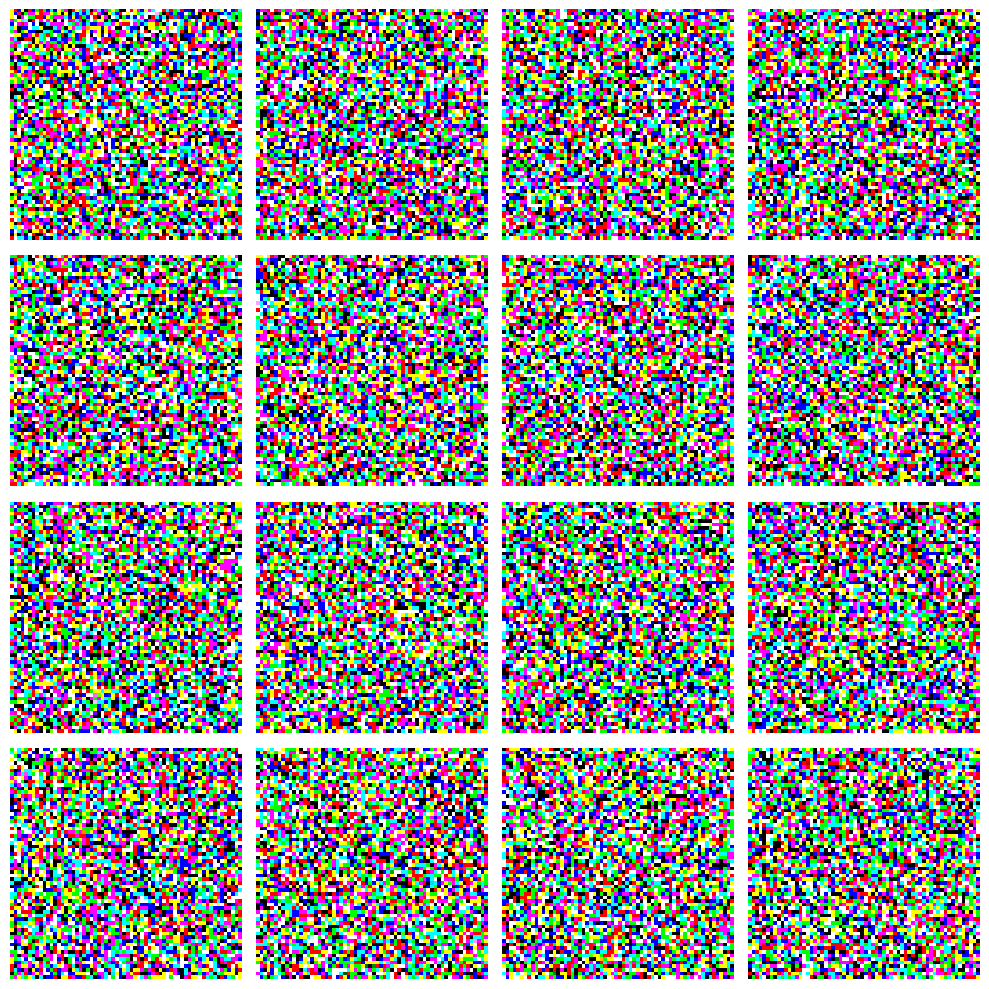

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [8]:
n_steps = 25
rho = 7
# From EDM2 code
# discretisation = solver_lib.get_edm_schedule(n_steps, sigma_min, sigma_max, rho)
discretisation = solver_lib.get_entropy_schedule(n_steps, entropy_checkpoint="../refs/img64_rescaled_entropic_time.pt")

In [9]:
rsde.reset()

em_solver = solver_lib.HeunSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

KeyboardInterrupt: 

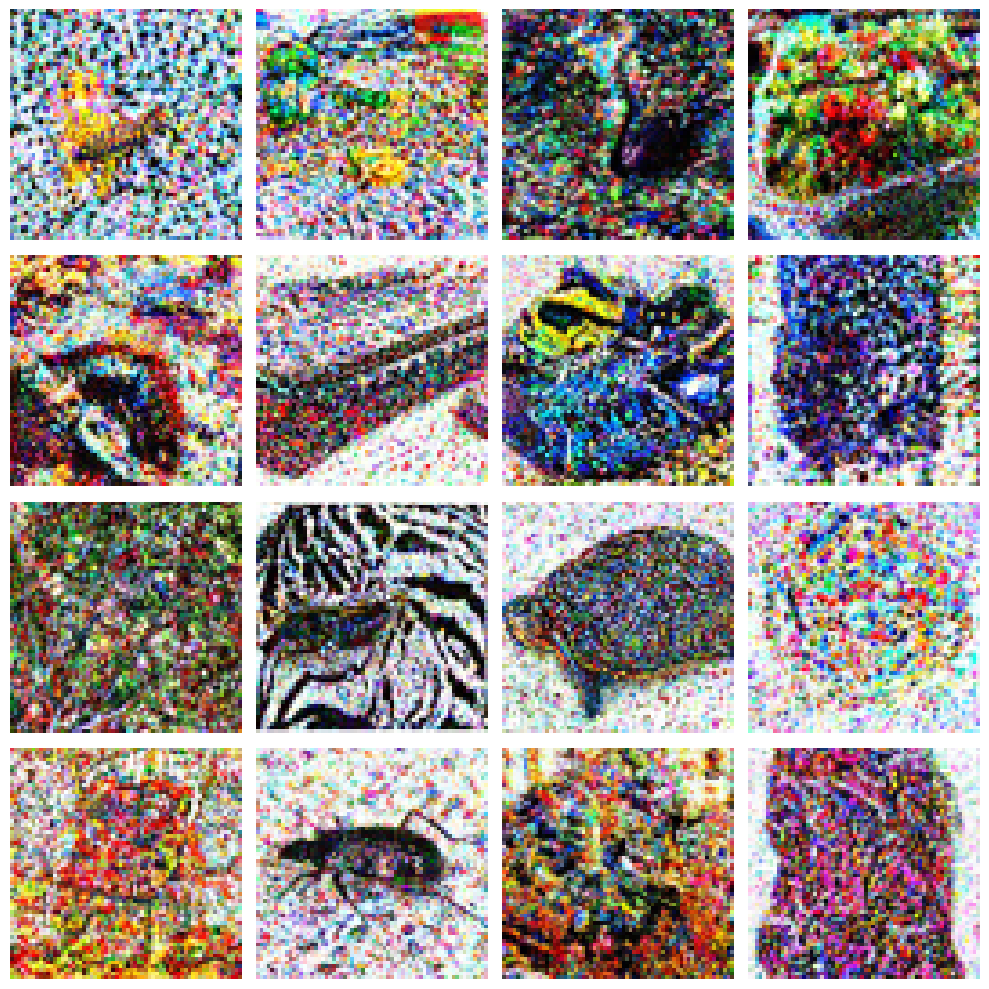

In [17]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [10]:
sigmas = []
sigmas_std = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())

In [11]:
sigmas = [80]
sigmas_std = [0]

rsde.reset()

pi_solver = solver_lib.PISolver2.create_heun_end_pi_solver(
    rsde,
    ode_threshold=0.05,
    n_ode_steps=5,
    ki=0.3,
    kp=0.1, 
    tau_a=0.06,
    tau_r=18,
    alpha=0.9,
    h_start=45,
    max_decrease=0.2,
    max_increase=5,
    interval=(80, 0.002),
    abs_error=False,
    batch_norm=False
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 35.0 h = -14.490992546081543 error = 0.9176698327064514
sigma = 20.50900650024414 h = -7.970895290374756 error = 0.4885942041873932
sigma = 12.538111686706543 h = -4.463723659515381 error = 0.3990910053253174
sigma = 8.07438850402832 h = -2.681234121322632 error = 0.31843093037605286
sigma = 5.393154144287109 h = -1.6834932565689087 error = 0.26939284801483154
sigma = 3.709660530090332 h = -1.0964974164962769 error = 0.23572561144828796
sigma = 2.6131632328033447 h = -0.7381735444068909 error = 0.2099197804927826
sigma = 1.8749897480010986 h = -0.5101841688156128 error = 0.19094055891036987
sigma = 1.3648054599761963 h = -0.36068570613861084 error = 0.1762215942144394
sigma = 1.004119873046875 h = -0.25978609919548035 error = 0.1648620367050171
sigma = 0.7443337440490723 h = -0.18962858617305756 error = 0.15681031346321106
sigma = 0.5547051429748535 h = -0.14048397541046143 error = 0.14923690259456635
sigma = 0.4142211973667145 h = -0.10498400777578354 error = 0.144236251711845

In [12]:
rsde.nfe / 16

49.25

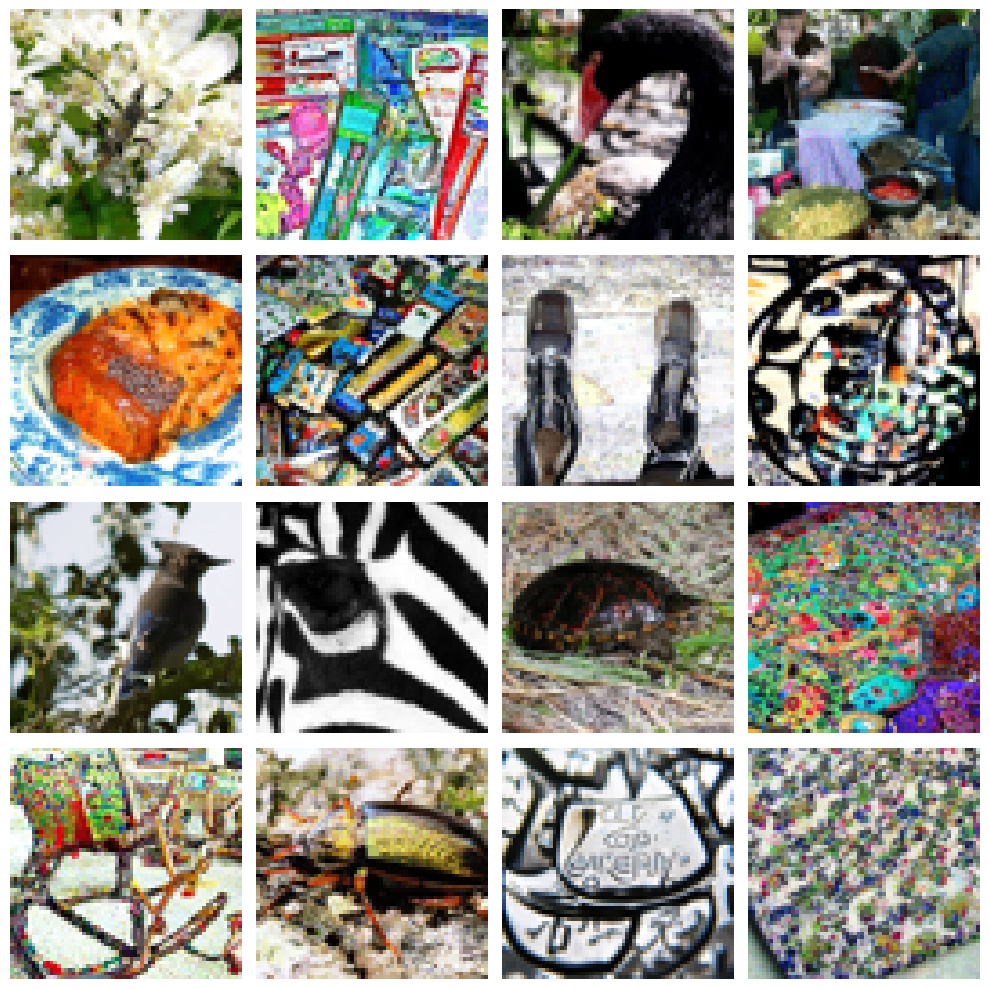

In [13]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [85]:
sigmas = [80]
sigmas_std = [0]

rsde.reset()

ggf_solver = solver_lib.GottaGoFast(
    rsde,
    tau_a=0.006,
    tau_r=20,
    h_start=18,
    r=0.3,
    alpha=0.9,
    interval=(80, 0.002)
).to("cuda")

x_ggf = ggf_solver.solve(noise.clone(), labels, pi_callback)

sigma = 62.0 h = -26.225658416748047 error = 0.20075076818466187
sigma = 62.0 h = -21.471851348876953 error = 1.3709847927093506
sigma = 40.52814483642578 h = -21.55942153930664 error = 0.6944253444671631
sigma = 40.52814483642578 h = -13.792837142944336 error = 3.119969367980957
sigma = 26.73531150817871 h = -14.516824722290039 error = 0.5935636162757874
sigma = 26.73531150817871 h = -9.065549850463867 error = 3.381714105606079
sigma = 17.669761657714844 h = -9.634001731872559 error = 0.5747135877609253
sigma = 17.669761657714844 h = -5.984122276306152 error = 3.4424362182617188
sigma = 11.685638427734375 h = -6.368109226226807 error = 0.5720754265785217
sigma = 11.685638427734375 h = -3.9660511016845703 error = 3.4121041297912598
sigma = 7.719588279724121 h = -4.211529731750488 error = 0.5761725902557373
sigma = 7.719588279724121 h = -2.6281023025512695 error = 3.3905231952667236
sigma = 5.091485977172852 h = -2.78208589553833 error = 0.5822879076004028
sigma = 5.091485977172852 h = 

In [86]:
rsde.nfe / 16

57.75

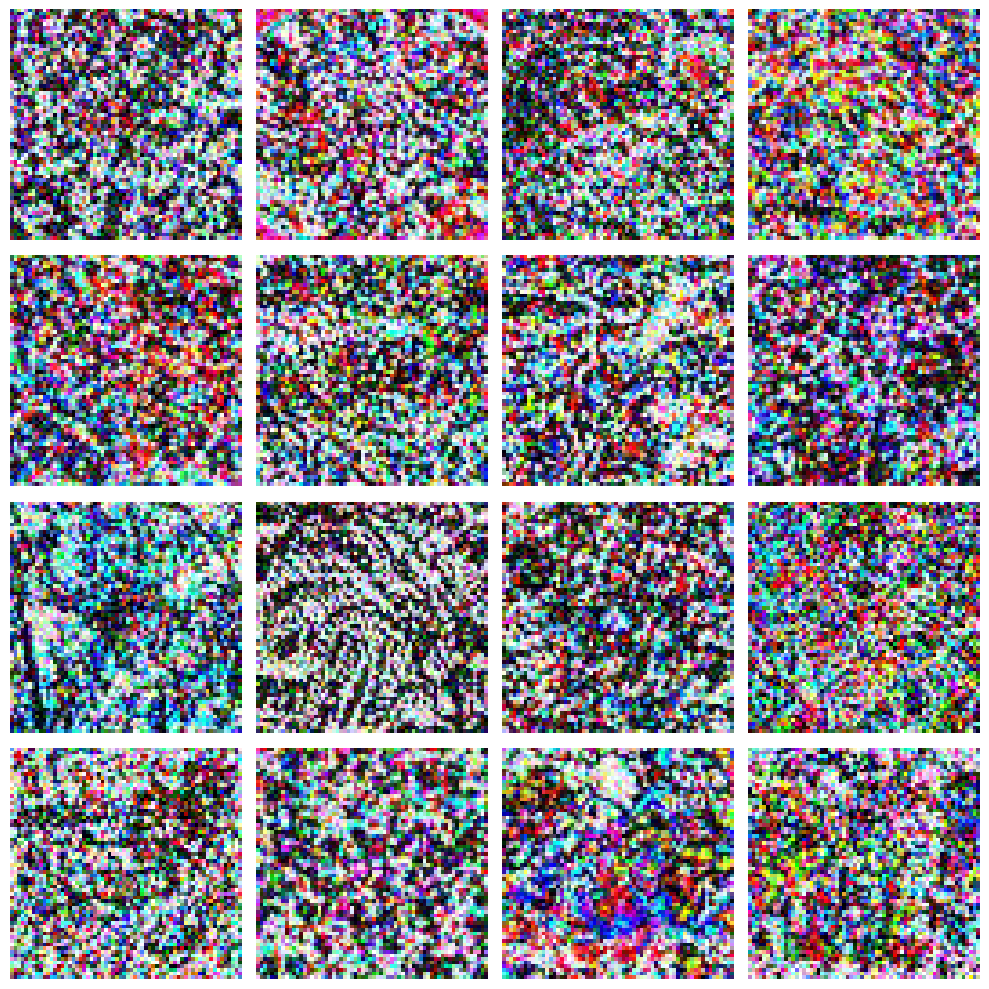

In [87]:
images = encoder.decode(x_ggf).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

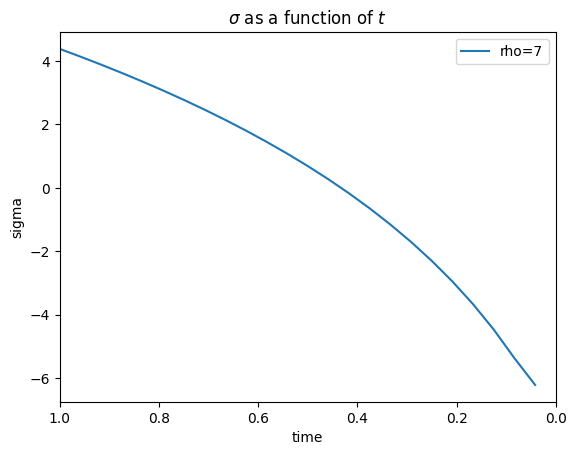

In [9]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas)), label="discovered")

# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) + torch.tensor(sigmas_std)))
# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) - torch.tensor(sigmas_std)))
plt.plot(torch.linspace(1, 0, len(discretisation)), torch.log(discretisation), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")

In [23]:
edm_solver = solver_lib.EDMSolver(solver_lib.get_edm_schedule(n_steps // 2), model).to("cuda")
x_edm = edm_solver.solve(noise.clone(), labels)

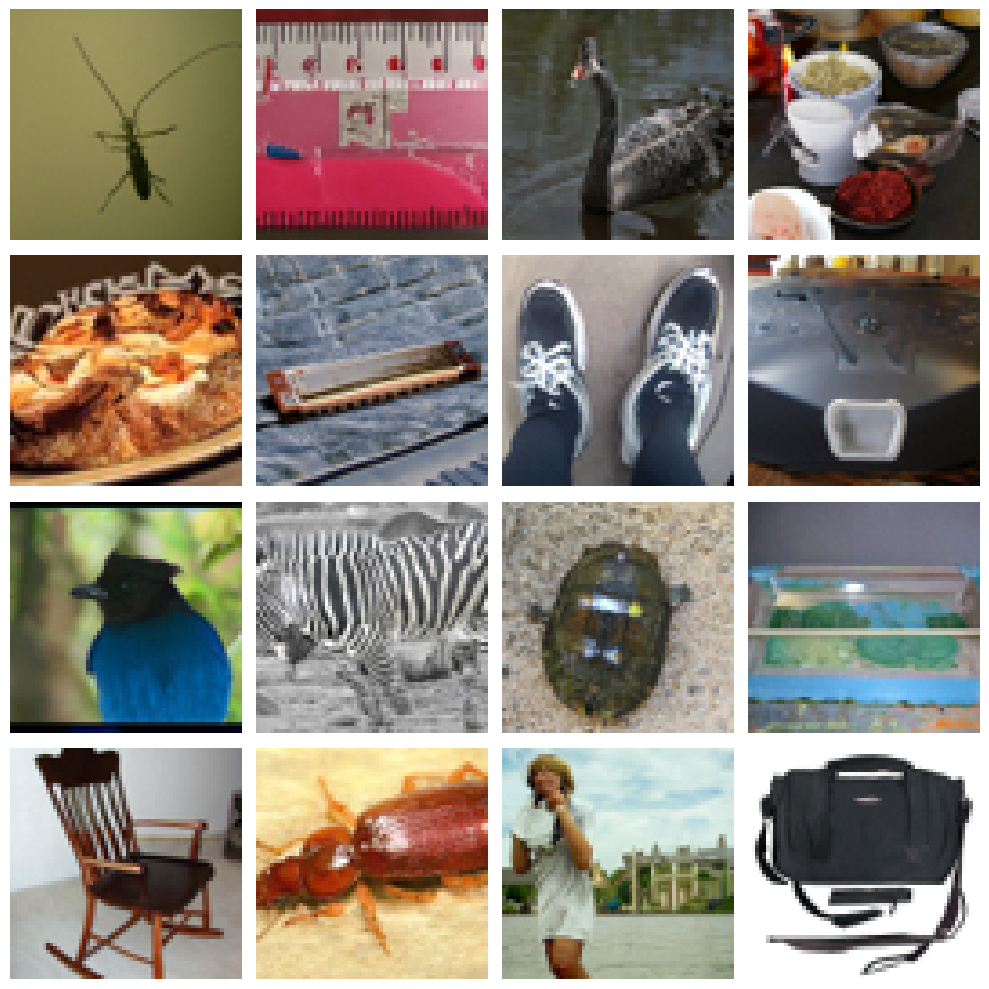

In [24]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())